[Home](../../README.md)

### Model Evaluation

This notebook is the final stage of my model before operations, I will be evaluating it on the testing data.

In [7]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("../../style_Matplotlib_charts.mplstyle")
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import pickle

In [8]:
filename = "my_saved_model.sav"
model = pickle.load(open(filename, "rb"))
print(f"Model loaded: {model}")

Model loaded: RandomForestClassifier(n_estimators=500, random_state=15)


####  Preparing data
I'm using the encoding map to convert my targets back to readable format, and defining my feature and target testing data.

In [9]:
testing_data = pd.read_csv("2.4.1.testing_data.csv")
X_test = testing_data.drop(columns=["dominant_biome"])
y_test = np.array(testing_data["dominant_biome"])

biome_map = {
    0: "beach",
    1: "birch_forest",
    2: "dark_forest",
    3: "forest",
    4: "meadow",
    5: "ocean",
    6: "plains",
    7: "river",
    8: "swamp",
    9: "taiga",
    10: "windswept_gravelly_hills",
    11: "windswept_savanna",
}
biome_labels = [biome_map[i] for i in sorted(set(y_test))]

print(f"Test samples: {len(X_test)}")
print(f"Biome classes in test set: {biome_labels}")

Test samples: 1954
Biome classes in test set: ['beach', 'birch_forest', 'dark_forest', 'forest', 'meadow', 'ocean', 'plains', 'river', 'swamp', 'taiga', 'windswept_gravelly_hills', 'windswept_savanna']


#### Evaluate accuracy

I'm using the `.score()` method to output an accuracy as a percentage.

In [10]:
y_pred = model.predict(X_test)

test_score = model.score(X_test, y_test)
print(f"Test accuracy: {test_score:.4f} ({test_score*100:.2f}%)")

Test accuracy: 0.9330 (93.30%)


#### Classification report

To evaluate the accuracy of the model more precisely, I'm using `classification_report`, which gives me data on each target individually.

In [11]:
print(classification_report(y_test, y_pred, target_names=biome_labels))

                          precision    recall  f1-score   support

                   beach       0.96      0.92      0.94        71
            birch_forest       0.98      0.95      0.97       198
             dark_forest       0.97      0.94      0.95       221
                  forest       0.96      0.98      0.97       288
                  meadow       0.00      0.00      0.00         2
                   ocean       0.94      0.96      0.95       518
                  plains       0.93      0.95      0.94       299
                   river       0.57      0.59      0.58       108
                   swamp       1.00      0.97      0.98        30
                   taiga       1.00      0.96      0.98       193
windswept_gravelly_hills       0.91      0.95      0.93        21
       windswept_savanna       0.00      0.00      0.00         5

                accuracy                           0.93      1954
               macro avg       0.77      0.76      0.77      1954
        

/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


#### Plot results

To better visualise and analyse my results, I'm using a heatmap of predictions that allows me to see what biomes were predicted accurately and where the model may have been confused.

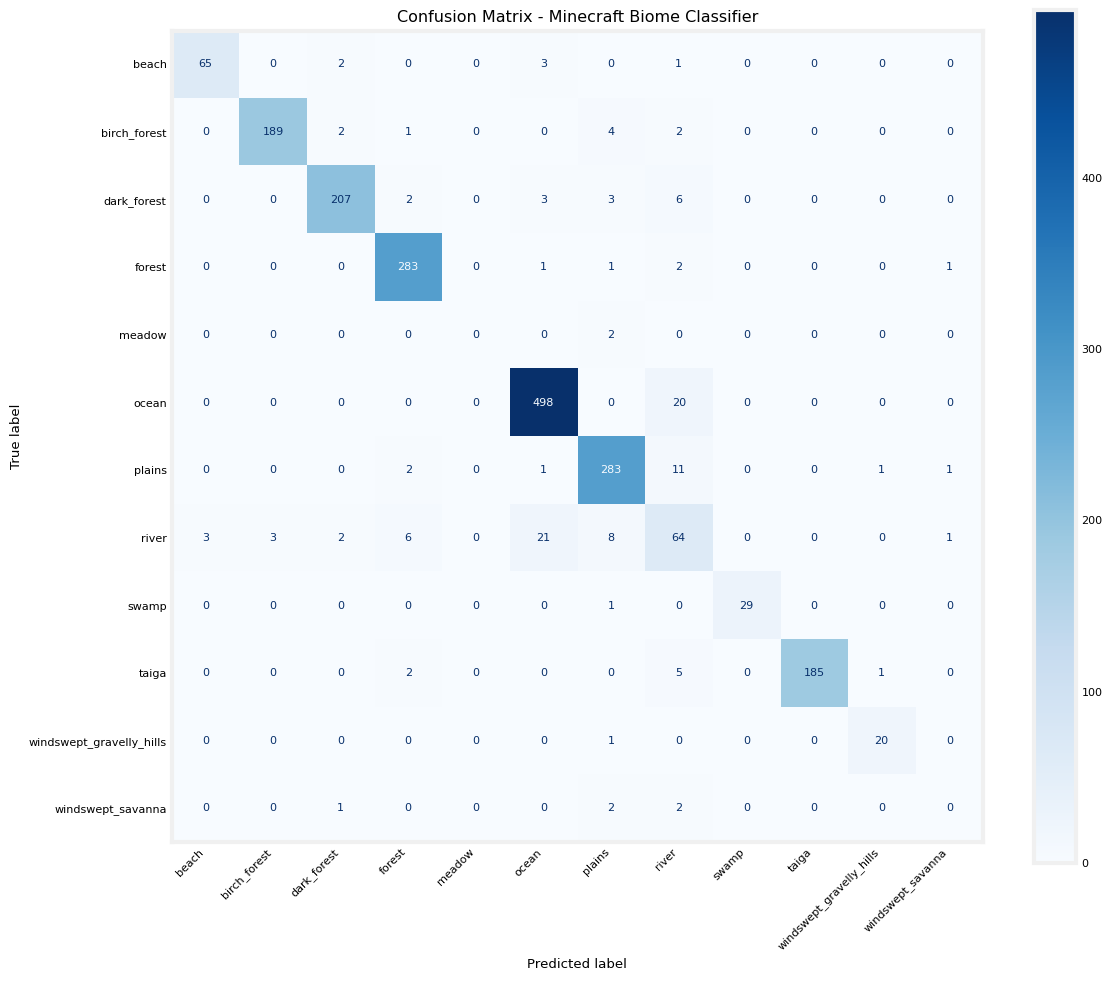

In [12]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=biome_labels)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, colorbar=True, cmap="Blues")
plt.title("Confusion Matrix - Minecraft Biome Classifier")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()